In [1]:
import sys

sys.path.append("..")
sys.path.append("../..")

In [2]:
import os
import copy
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from os.path import join as pjoin

from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch import nn

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from utils.misc import load_config, load_model_from_checkpoint, precision_recall_f1_score
from datasets.data_preparation import prepare_data

/home/nasim/anaconda3/envs/ML/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
exp_path = '../../results/dl.vit/2023-09-11 14Hr 45Min 02Sec IST+0530'

config = load_config('.', exp_path, 'hyperparameters.yaml')

In [4]:
trainer_config = config['trainer']
data_config = config['data']

model_name = config['model']['__name__']

checkpoint_name = trainer_config['checkpoint_name']
device = trainer_config['device']
batch_size = trainer_config['batch_size']

patch_size = data_config['patch']['patch_size']
lithology_classes = data_config['lithology_classes']

config['root'] = '../..'

In [5]:
if model_name.startswith('dl'):
    if model_name.endswith('vit'):
        if config['model']['autoregressive']:
            from model.vit_autoregressor import build_model
            from engine.autoregressor import validation_engine as blind_engine
        else:
            from model.vit import build_model
            from engine.vit import validation_engine as blind_engine
    elif model_name.endswith('ann'):
        from model.ann import build_model

model = build_model(config)

Building the model...


In [6]:
from peft import LoraConfig, get_peft_model

if config['model']['use_lora']:
     print('Using LORA')
     lora_config = LoraConfig(**config['model']['lora'])
     model = get_peft_model(model, lora_config)
     model, _ = load_model_from_checkpoint(model, checkpoint_name, exp_path, device)
else:
     print('Not using LORA')
     model, _ = load_model_from_checkpoint(model, checkpoint_name, exp_path, device)
model = model.to(device)

Not using LORA
Loading model from checkpoint...


In [14]:
config['data']['x_file_name'] = 'blind_X.h5'
config['data']['y_file_name'] = 'blind_Y.h5'

# config['data']['patch']['stride'] = 15#config['data']['patch']['patch_size']

x_blind, _, y_blind, _, _ = prepare_data(config, test = True, scaler_save=False)

blind_dataset = TensorDataset(x_blind, y_blind)
blindloader = DataLoader(blind_dataset, batch_size=batch_size, shuffle=True)

Preparing the data...
Creating scaler for GR...
Creating scaler for NPHI...
Creating scaler for DPHI...
Creating scaler for ILD...
Creating scaler for VSH...


Creating Patches: 100%|██████████| 10/10 [00:00<00:00, 301.48it/s]

Number of classes: 5 and shape of x_train: torch.Size([17, 150, 5])


In [15]:
# _, x_val, _, y_val, _ = prepare_data(config)

# valdataset = TensorDataset(x_val, y_val)
# valloader = DataLoader(valdataset, batch_size=batch_size, shuffle=False)

In [16]:
# invert key as value and value as key
lithology_names = {v: k for k, v in lithology_classes.items()}

In [17]:
classification_criterion = nn.CrossEntropyLoss()
regression_criterion = nn.MSELoss()

In [18]:
# blind_loss, blind_accuracy, blind_cm = blind_engine(1,
#                                                     model,
#                                                     blindloader,
#                                                     criterion,
#                                                     1,
#                                                     device)

val_loss, lith_val_loss, phi_val_loss, sw_val_loss, val_accuracy, cm_val = blind_engine(1,
                                                    model,
                                                    blindloader,
                                                    regression_criterion,
                                                    classification_criterion,
                                                    1,
                                                    config['model']['loss_weights'],
                                                    device,)

Val - Epoch 2/1: 100%|██████████| 1/1 [00:00<00:00, 21.22it/s]


In [19]:
phi_val_loss, sw_val_loss

(0.00038257437317090417, 0.018251643351460078)

In [20]:
phi_val_loss, sw_val_loss

(0.00038257437317090417, 0.018251643351460078)

/home/nasim/phd/petro_AViT/notebooks/ml/../../utils/misc.py:450: RuntimeWarning: invalid value encountered in divide
  recall = np.diag(cm) / np.sum(cm, axis = 1)


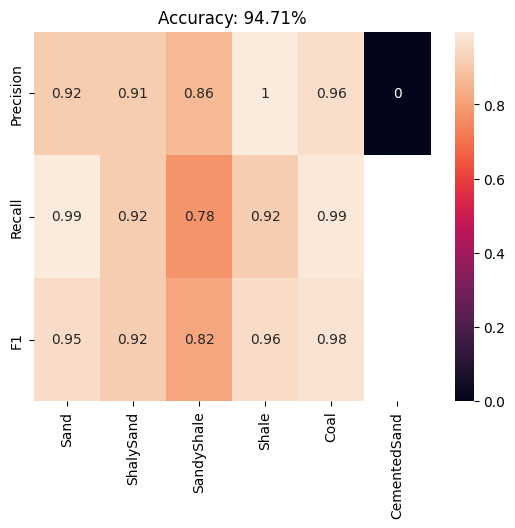

In [21]:
precision_recall_f1_score(cm_val, lithology_classes, save_path='')

In [ ]:
target_names = {v: k for k, v in lithology_classes.items()}

In [ ]:
sample_idx = np.random.randint(0, batch_size)
depth_idx = np.random.randint(0, patch_size)

true_class_idx = target[sample_idx][depth_idx].item()
true_lithology = lithology_names[true_class_idx]

prediction_class_idx = np.argmax(output[sample_idx][depth_idx]).item()
predicted_lithology = lithology_names[prediction_class_idx]

prediction_probability = output[sample_idx][depth_idx][prediction_class_idx].item()
true_class_probability = output[sample_idx][depth_idx][true_class_idx].item()

prediction_reward = get_simulated_rewards_as_labels_for_reward_model(true_class_probability)

print("Predicted lithology: ", 
      predicted_lithology, 
      '\n\twith probability: ', 
      prediction_probability, 
      '\n\tTrue class probability: ',
      true_class_probability,
      "\nTrue lithology: ", 
      true_lithology,
      '\nReward: ',
      prediction_reward)